In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from kagglehub import KaggleDatasetAdapter

sns.set_theme(style="whitegrid", context="notebook")


def _distplot_compat(a, ax=None, **kwargs):
    kde_kws = kwargs.pop("kde_kws", {}) or {}
    if ax is None:
        ax = plt.gca()
    sns.histplot(a, ax=ax, kde=True, stat="density", kde_kws=kde_kws, **kwargs)
    return ax


if not hasattr(sns, "distplot"):
    sns.distplot = _distplot_compat

import nicaviz  # noqa: F401 — registers `DataFrame.nica` accessor


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_SLUG = "nicapotato/osrs-money-makers"
GUIDES_FILE = "input_output.parquet"
METHODS_FILE = "methods.parquet"
SNAPSHOTS_DIR = "snapshots"
TOP_N_METHODS = 20


def load_parquet(file_path: str) -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        matches = sorted(
            kaggle_root.rglob(file_path),
            key=lambda p: p.stat().st_size,
            reverse=True,
        )
        if matches:
            print(f"Kaggle input: {matches[0]}")
            return pd.read_parquet(matches[0])

    local = Path("data") / file_path
    if local.exists():
        print(f"Local: {local.resolve()}")
        return pd.read_parquet(local)

    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATA_SLUG,
        file_path,
    )
    print(f"kagglehub: {DATA_SLUG}/{file_path}")
    return df


def load_snapshots() -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        paths = sorted(kaggle_root.rglob(f"{SNAPSHOTS_DIR}/**/*.parquet"))
        assert paths, f"no snapshot parquet under {kaggle_root}/{SNAPSHOTS_DIR}"
        print(f"Kaggle snapshots: {len(paths)} partition file(s)")
        frames = [pd.read_parquet(p) for p in paths]
        snapshots = pd.concat(frames, ignore_index=True)
        assert "method_id" in snapshots.columns, "expected OSRS method snapshots"
        return snapshots

    local_root = Path("data") / SNAPSHOTS_DIR
    if local_root.exists():
        paths = sorted(local_root.rglob("*.parquet"))
        assert paths, f"no parquet under {local_root}"
        print(f"Local snapshots: {len(paths)} partition file(s)")
        frames = [pd.read_parquet(p) for p in paths]
        snapshots = pd.concat(frames, ignore_index=True)
        assert "method_id" in snapshots.columns, "expected OSRS method snapshots under data/snapshots"
        return snapshots

    root = Path(kagglehub.dataset_download(DATA_SLUG))
    paths = sorted((root / SNAPSHOTS_DIR).rglob("*.parquet"))
    assert paths, f"no snapshot parquet under {root}/{SNAPSHOTS_DIR}"
    print(f"kagglehub snapshots: {len(paths)} partition file(s)")
    frames = [pd.read_parquet(p) for p in paths]
    snapshots = pd.concat(frames, ignore_index=True)
    assert "method_id" in snapshots.columns, "expected OSRS method snapshots"
    return snapshots


guides = load_parquet(GUIDES_FILE)
methods = load_parquet(METHODS_FILE)
snapshots = load_snapshots()

print("Guides:", guides.shape[0], "rows ×", guides.shape[1], "cols")
print("Methods:", methods.shape[0], "rows ×", methods.shape[1], "cols")
print("Snapshots:", snapshots.shape[0], "rows ×", snapshots.shape[1], "cols")

df = guides.merge(methods, on="method_id", how="left", validate="m:1")
print("Joined:", df.shape[0], "rows ×", df.shape[1], "cols")
print("First 5 records:")
display(df.head())


Local: /Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/data/input_output.parquet
Local: /Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/data/methods.parquet
Local snapshots: 14 partition file(s)
Guides: 30 rows × 8 cols
Methods: 12 rows × 6 cols
Snapshots: 168 rows × 10 cols
Joined: 30 rows × 13 cols
First 5 records:


,line_id,method_id,io_type,wiki_slug,item_name,item_id,qty_per_completion,first_scraped_at,method_name,method_url,categories,intensity,is_members
0,2ad09b2d9a720585,ef79906e121e7ea6,input,Raw_marlin,Raw marlin,32349,1.0,2026-05-21 12:00:00+00:00,Cutting raw marlin,/w/Money_making_guide/Cutting_raw_marlin,"[Skilling, Fishing]",Low,True
1,0ad0de67b0efbfef,ef79906e121e7ea6,output,Marlin_scales,Marlin scales,2,3.0,2026-05-21 12:00:00+00:00,Cutting raw marlin,/w/Money_making_guide/Cutting_raw_marlin,"[Skilling, Fishing]",Low,True
2,889256207439bc76,ef79906e121e7ea6,output,Fine_fish_offcuts,Fine fish offcuts,1,0.5,2026-05-21 12:00:00+00:00,Cutting raw marlin,/w/Money_making_guide/Cutting_raw_marlin,"[Skilling, Fishing]",Low,True
3,a6fde5c2bb5bf587,23bcfd68b188cd5a,input,Grimy_torstol,Grimy torstol,269,1.0,2026-05-21 12:00:00+00:00,Cleaning grimy herb,/w/Money_making_guide/Cleaning_grimy_herb,"[Skilling, Herblore]",Low,True
4,07805647d45f544f,23bcfd68b188cd5a,output,Torstol,Torstol,270,1.0,2026-05-21 12:00:00+00:00,Cleaning grimy herb,/w/Money_making_guide/Cleaning_grimy_herb,"[Skilling, Herblore]",Low,True


In [3]:
display(df.sample(min(5, len(df)), random_state=42))
display(df.dtypes.to_frame("dtype"))
display(df[["qty_per_completion"]].describe().T)

ID_COLS = ["line_id", "method_id", "item_id"]
CAT_COLS = ["io_type", "wiki_slug", "item_name", "method_name", "method_url", "intensity"]
BOOL_COLS = ["is_members"]
NUM_COLS = ["qty_per_completion"]

# Primary category tag (first path segment) for stratified plots
df["primary_category"] = df["categories"].apply(
    lambda cats: cats[0] if isinstance(cats, (list, tuple)) and len(cats) else "Unknown"
)

print(f"{df['method_id'].nunique()} distinct methods; {df['io_type'].nunique()} I/O types")


,line_id,method_id,io_type,wiki_slug,item_name,item_id,qty_per_completion,first_scraped_at,method_name,method_url,categories,intensity,is_members
27,3ba18fdde92fafad,5f562bd52470e6e3,output,Runite_ore,Runite ore,451,1.000,2026-05-21 12:00:00+00:00,Mining runite ore,/w/Money_making_guide/Mining_runite_ore,"[Skilling, Mining]",Medium,True
15,456a23a3eaed695c,87a8388a8d4ba4f1,input,Steel_bar,Steel bar,2353,1.000,2026-05-21 12:00:00+00:00,Smithing cannonballs,/w/Money_making_guide/Smithing_cannonballs,"[Skilling, Smithing]",Low,True
23,bb35a68c94585054,80b3a4383d1135c0,output,Tanzanite_fang,Tanzanite fang,12922,0.008,2026-05-21 12:00:00+00:00,Killing Zulrah,/w/Money_making_guide/Killing_Zulrah,"[Combat, Bossing]",High,True
17,75291958a47f9279,434a16b075411a27,input,Nature_rune,Nature rune,561,1.000,2026-05-21 12:00:00+00:00,High alching,/w/Money_making_guide/High_alching,[Magic],Low,False
8,51ca87cedfef2f0b,c3ca6cc7981477fa,output,Dragonstone,Dragonstone,1615,0.150,2026-05-21 12:00:00+00:00,Killing Vorkath,/w/Money_making_guide/Killing_Vorkath,"[Combat, Bossing]",High,True


,dtype
line_id,str
method_id,str
io_type,str
wiki_slug,str
item_name,str
item_id,int64
qty_per_completion,float64
first_scraped_at,"datetime64[us, UTC]"
method_name,str
method_url,str


,count,mean,std,min,25%,50%,75%,max
qty_per_completion,30.0,6843.589533,26010.608911,0.008,1.0,1.0,3.75,105000.0


12 distinct methods; 2 I/O types


In [4]:
cat_view = df[["io_type", "intensity", "primary_category", "is_members"]].copy()
cat_view["is_members"] = cat_view["is_members"].map({True: "Members", False: "Free-to-play"})
display(cat_view.nica.categorical_describe())


Dataframe Dimension: 30 Rows, 4 Columns


,Unique,Missing,dtype,ValCount 1,Occ,ValCount 2,Occ,ValCount 3,Occ,ValCount 4,Occ,ValCount 5,Occ
Column,,,,,,,,,,,,,
io_type,2,0,str,input,16,output,14.0,NaN,NaN,NaN,NaN,NaN,NaN
intensity,3,0,str,Low,13,Medium,9.0,High,8.0,NaN,NaN,NaN,NaN
primary_category,1,0,str,Unknown,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_members,2,0,str,Members,22,Free-to-play,8.0,NaN,NaN,NaN,NaN,NaN,NaN


/var/folders/wb/qw2d5rfj7p95jckpfvkk7xsr0000gn/T/ipykernel_70259/1027263535.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="deep")
/var/folders/wb/qw2d5rfj7p95jckpfvkk7xsr0000gn/T/ipykernel_70259/1027263535.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="deep")
/var/folders/wb/qw2d5rfj7p95jckpfvkk7xsr0000gn/T/ipykernel_70259/1027263535.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="deep")
/

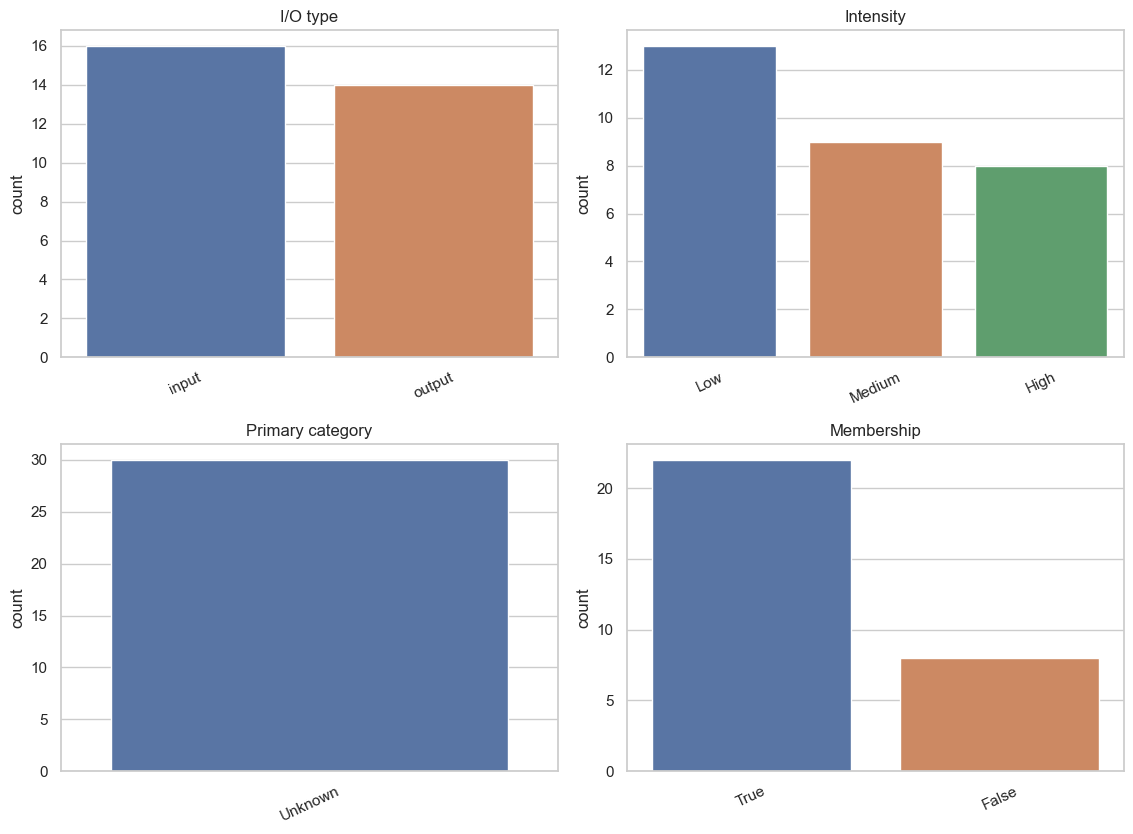

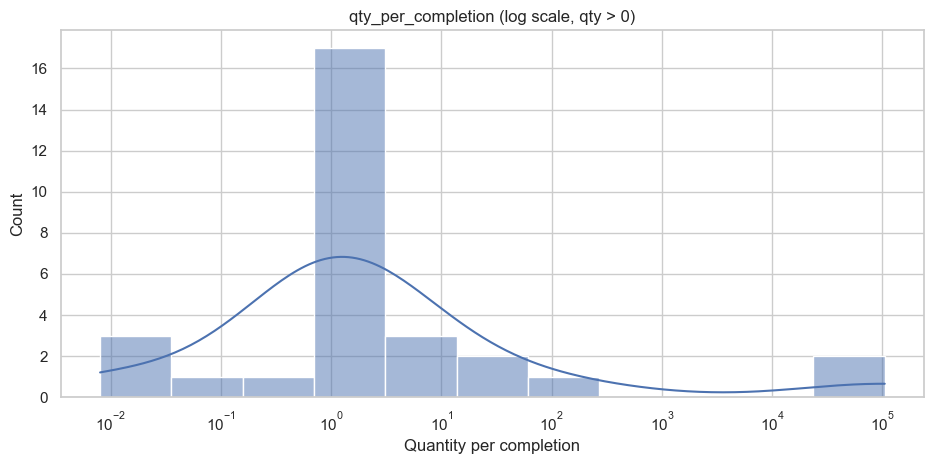

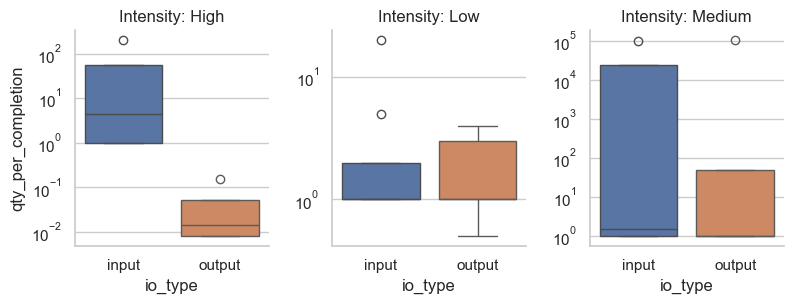

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.5))
for ax, col, title in zip(
    axes.ravel(),
    ["io_type", "intensity", "primary_category", "is_members"],
    ["I/O type", "Intensity", "Primary category", "Membership"],
):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette="deep")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# qty distribution — log x for wide GP/item ranges
fig, ax = plt.subplots(figsize=(9.5, 4.8))
positive_qty = df.loc[df["qty_per_completion"] > 0, "qty_per_completion"]
sns.histplot(positive_qty, log_scale=True, kde=True, ax=ax)
ax.set_title("qty_per_completion (log scale, qty > 0)")
ax.set_xlabel("Quantity per completion")
plt.tight_layout()
plt.show()

# FacetGrid: qty by io_type across intensity strata
plot_df = df[df["qty_per_completion"] > 0].copy()
g = sns.FacetGrid(
    plot_df,
    col="intensity",
    hue="io_type",
    col_order=sorted(plot_df["intensity"].unique()),
    height=3.2,
    aspect=1.05,
    sharex=False,
    sharey=False,
)
g.map_dataframe(sns.boxplot, y="qty_per_completion", x="io_type", order=["input", "output"])
g.set(yscale="log")
g.set_titles(col_template="Intensity: {col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=0)
if g._legend is not None:
    g._legend.set_bbox_to_anchor((1.02, 0.98))
    g._legend.set_loc("upper left")
plt.subplots_adjust(top=0.88, right=0.78)
plt.show()


Top 12 methods by latest rank (2026-05-23); 14 scrape day(s) in series


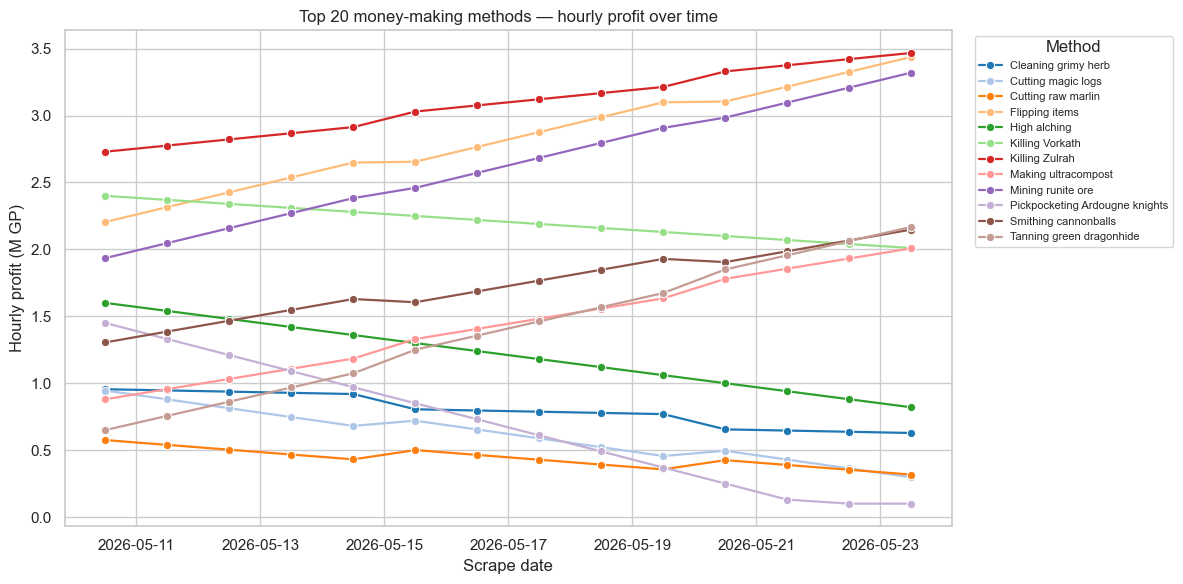

Latest hourly profit (GP) for tracked methods:


method_name,Cleaning grimy herb,Cutting magic logs,Cutting raw marlin,Flipping items,High alching,Killing Vorkath,Killing Zulrah,Making ultracompost,Mining runite ore,Pickpocketing Ardougne knights,Smithing cannonballs,Tanning green dragonhide
scrape_timestamp,,,,,,,,,,,,
2026-05-21 12:00:00+00:00,"646,000","429,000","389,000","3,216,000","940,000","2,070,000","3,376,000","1,856,000","3,097,000","130,000","1,986,000","1,956,000"
2026-05-22 12:00:00+00:00,"637,000","363,000","353,000","3,327,000","880,000","2,040,000","3,422,000","1,932,000","3,209,000","100,000","2,067,000","2,062,000"
2026-05-23 12:00:00+00:00,"628,000","297,000","317,000","3,438,000","820,000","2,010,000","3,468,000","2,008,000","3,321,000","100,000","2,148,000","2,168,000"


In [6]:
snap_ts = snapshots.merge(
    methods[["method_id", "method_name"]],
    on="method_id",
    how="inner",
    validate="m:1",
)
assert snap_ts["scrape_timestamp"].nunique() >= 1

latest_ts = snap_ts["scrape_timestamp"].max()
latest_ranked = snap_ts.loc[snap_ts["scrape_timestamp"] == latest_ts].sort_values("rank")
top_method_ids = latest_ranked.head(TOP_N_METHODS)["method_id"].tolist()
assert top_method_ids, "no methods in latest snapshot"

plot_ts = snap_ts.loc[snap_ts["method_id"].isin(top_method_ids)].copy()
plot_ts = plot_ts.sort_values(["method_name", "scrape_timestamp"])
plot_ts["hourly_profit_m"] = plot_ts["hourly_profit_gp"] / 1_000_000

print(
    f"Top {len(top_method_ids)} methods by latest rank ({latest_ts.date()}); "
    f"{plot_ts['scrape_timestamp'].nunique()} scrape day(s) in series"
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=plot_ts,
    x="scrape_timestamp",
    y="hourly_profit_m",
    hue="method_name",
    marker="o",
    linewidth=1.6,
    ax=ax,
    palette="tab20",
)
ax.set_title(f"Top {TOP_N_METHODS} money-making methods — hourly profit over time")
ax.set_xlabel("Scrape date")
ax.set_ylabel("Hourly profit (M GP)")
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

wide = (
    plot_ts.pivot_table(
        index="scrape_timestamp",
        columns="method_name",
        values="hourly_profit_gp",
        aggfunc="first",
    )
    .sort_index()
)
print("Latest hourly profit (GP) for tracked methods:")
display(wide.tail(3).style.format("{:,.0f}"))


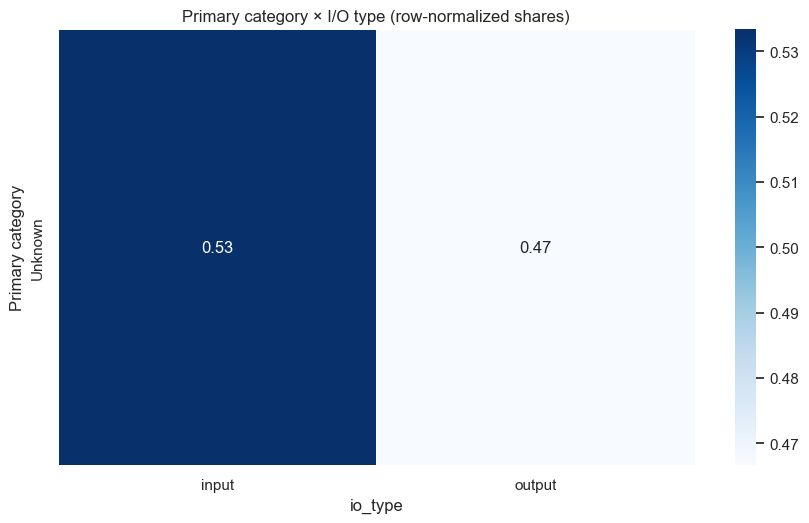

io_type,input,output
primary_category,,
Unknown,0.533,0.467


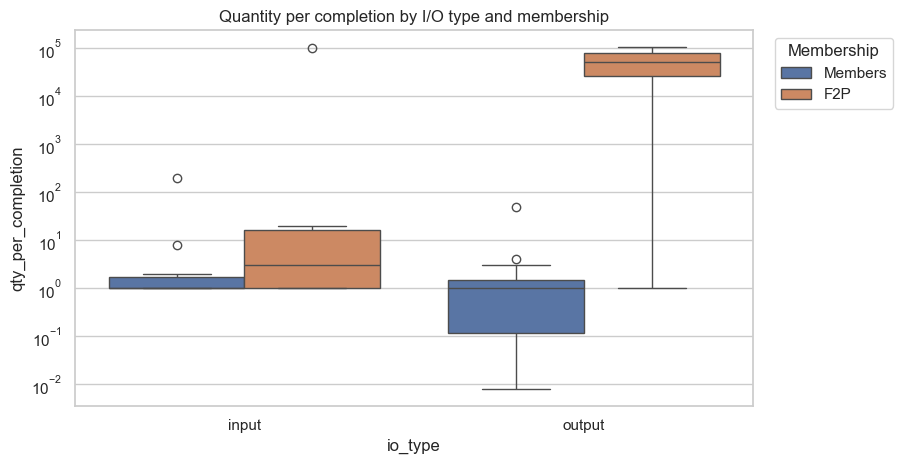

In [7]:
ct = pd.crosstab(df["primary_category"], df["io_type"], normalize="index")
fig, ax = plt.subplots(figsize=(8.8, 5.4))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", linewidths=0.4, ax=ax)
ax.set_title("Primary category × I/O type (row-normalized shares)")
ax.set_ylabel("Primary category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(ct.style.format("{:.3f}").background_gradient(cmap="Blues", axis=None))

fig, ax = plt.subplots(figsize=(9.2, 4.8))
plot_q = df[df["qty_per_completion"] > 0].copy()
plot_q["membership"] = plot_q["is_members"].map({True: "Members", False: "F2P"})
sns.boxplot(
    data=plot_q,
    x="io_type",
    y="qty_per_completion",
    hue="membership",
    order=["input", "output"],
    ax=ax,
)
ax.set_yscale("log")
ax.set_title("Quantity per completion by I/O type and membership")
ax.legend(title="Membership", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [8]:
input_df = df[df["io_type"] == "input"].copy()
pivot = input_df.pivot_table(
    index="primary_category",
    columns="intensity",
    values="qty_per_completion",
    aggfunc="mean",
)
display(pivot.style.format("{:,.1f}").background_gradient(cmap="YlOrRd", axis=None))

# Top items by how many methods reference them
item_freq = (
    df.groupby(["item_name", "io_type"], as_index=False)
    .agg(methods_using=("method_id", "nunique"), avg_qty=("qty_per_completion", "mean"))
    .sort_values("methods_using", ascending=False)
)
print("Most reused items across guides:")
display(item_freq.head(10))


intensity,High,Low,Medium
primary_category,,,
Unknown,52.5,3.9,"25,001.0"


Most reused items across guides:


,item_name,io_type,methods_using,avg_qty
2,Coins,input,2,50010.000
3,Coins,output,2,52525.000
0,Anglerfish,input,1,8.000
15,Raw marlin,input,1,1.000
26,Vorkath's head,output,1,0.020
25,Volcanic ash,input,1,2.000
24,Ultracompost,output,1,1.000
23,Toxic blowpipe,input,1,1.000
22,Torstol,output,1,1.000
21,Tanzanite fang,output,1,0.008
